# **Gradient Boosting**

# Gradient Boosting

Gradient Boosting is a powerful ensemble machine learning technique used for both regression and classification tasks. It builds a model in a sequential manner, where each new model attempts to correct the errors (residuals) made by the previous models.

When you implement various models for gradient boosting, the first model of all is simply the mean of the target column. It means whatever input you give to the first model, it will simply return one single output which is the mean of the target column.

Since we have out first prediction, in that case we will calculate how much is the deviation of the predicted data from the actual data. `Actual - Predicted = error`, and this `error` (error of the every single inputs) will be sent to the next model.

After dealing with the first model, we will now move to the second model. Here one key differenct is, now we will make the `error` as our target column in the second model. The more accurately second model catches the errors the more we will be close to the actual predictions. On the second model we will have another `error` predictions.

And this entire process goes on and on with rest of the models.

### 1. Core Concept
Unlike Random Forest (which builds trees in parallel), Gradient Boosting builds trees **sequentially**. Each subsequent tree is trained to predict the **residual errors** of the combined ensemble of all previous trees.

### 2. How it Works (Step-by-Step)
1.  **Initialize:** Start with a simple model (usually a constant value, like the mean of the target variable).
2.  **Calculate Residuals:** Compute the difference between the actual values and the current predictions.
3.  **Train Weak Learner:** Fit a new weak learner (typically a shallow Decision Tree) to the residuals.
4.  **Update Model:** Add the new tree's predictions to the previous ensemble's predictions, scaled by a **learning rate ($\eta$)**.
5.  **Repeat:** Iterate steps 2-4 for a specified number of iterations ($n\_estimators$).

### 3. Mathematical Intuition
Gradient Boosting treats the optimization problem as a **Gradient Descent** in the functional space.
*   **Loss Function ($L$):** Measures how well the model fits the data (e.g., Mean Squared Error for regression, Log-Loss for classification).
*   **Negative Gradient:** The residuals are actually the negative gradients of the loss function with respect to the predicted values. By fitting a tree to these residuals, we are moving the model in the direction that minimizes the loss.

$$F_{m}(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Where:
*   $F_m(x)$ is the model at step $m$.
*   $\eta$ is the learning rate.
*   $h_m(x)$ is the weak learner fitted to the residuals of $F_{m-1}$.

### 4. Key Hyperparameters
*   **`n_estimators`**: The number of trees to build. Too many can lead to overfitting.
*   **`learning_rate` (Shrinkage)**: Scales the contribution of each tree. Smaller values require more trees but generally result in better generalization.
*   **`max_depth`**: Controls the depth of individual trees (usually kept small, e.g., 3-5).
*   **`subsample`**: The fraction of samples to be used for fitting the individual base learners (Stochastic Gradient Boosting).

### 5. Pros and Cons
**Pros:**
*   High predictive accuracy.
*   Flexible: Can optimize various loss functions.
*   Handles missing data and non-linear relationships well.

**Cons:**
*   Prone to **overfitting** if not tuned properly.
*   Computationally expensive (sequential nature makes it harder to parallelize than Random Forest).
*   Sensitive to outliers (since it focuses on correcting errors).

### 6. Popular Implementations
*   **Scikit-Learn:** `GradientBoostingClassifier` and `GradientBoostingRegressor`.
*   **XGBoost:** Optimized distributed gradient boosting library.
*   **LightGBM:** Uses histogram-based algorithms for faster training.
*   **CatBoost:** Specifically optimized for handling categorical features.



---


# Additive Modelling

An **Additive Model** is a non-parametric regression method where the predictive relationship between the independent variables and the dependent variable is modeled as a sum of univariate smooth (small) functions. Unlike standard linear regression, which assumes a strictly linear relationship, additive models allow for non-linear relationships while maintaining interpretability.

## Mathematical Representation

The general form of an additive model is:

$$Y = \alpha + \sum_{j=1}^{p} f_j(X_j) + \epsilon$$

Where:
*   **$Y$**: The dependent variable (target).
*   **$\alpha$**: The intercept (constant term).
*   **$X_j$**: The $j$-th predictor variable.
*   **$f_j$**: A smooth, non-parametric function (e.g., splines, polynomials) applied to the $j$-th predictor.
*   **$\epsilon$**: The error term.

## Key Characteristics
1.  **Flexibility**: It can capture non-linear patterns without requiring the user to specify the exact functional form (like $X^2$ or $\log(X)$).
2.  **Interpretability**: Because the model is additive, you can examine the effect of each predictor $X_j$ on $Y$ individually by looking at $f_j$, holding other variables constant.
3.  **No Interactions**: In its basic form, it assumes that the effect of one predictor does not depend on the value of another.


## Example: Predicting House Prices

Suppose we want to predict the **Price** of a house based on two features: **Square Footage** and **Age of the House**.

### 1. Linear Model Approach
A standard linear model would assume:
$$\text{Price} = \beta_0 + \beta_1(\text{SqFt}) + \beta_2(\text{Age})$$
This implies that every additional square foot adds the exact same dollar amount to the price, regardless of whether the house is 500 or 5,000 sq ft.

### 2. Additive Model Approach
An additive model would represent it as:
$$\text{Price} = \alpha + f_1(\text{SqFt}) + f_2(\text{Age})$$

*   **$f_1(\text{SqFt})$**: Might show that price increases rapidly for the first 2,000 sq ft but levels off for extremely large mansions (diminishing returns).
*   **$f_2(\text{Age})$**: Might show that price drops quickly for the first 10 years, stays flat for "middle-aged" houses, and then increases for "historic" homes (over 100 years old).

### Why it works:
The additive model captures these complex, non-linear "shapes" for Square Footage and Age independently and then simply **adds** their contributions together to get the final price prediction.

### How Additive Model works

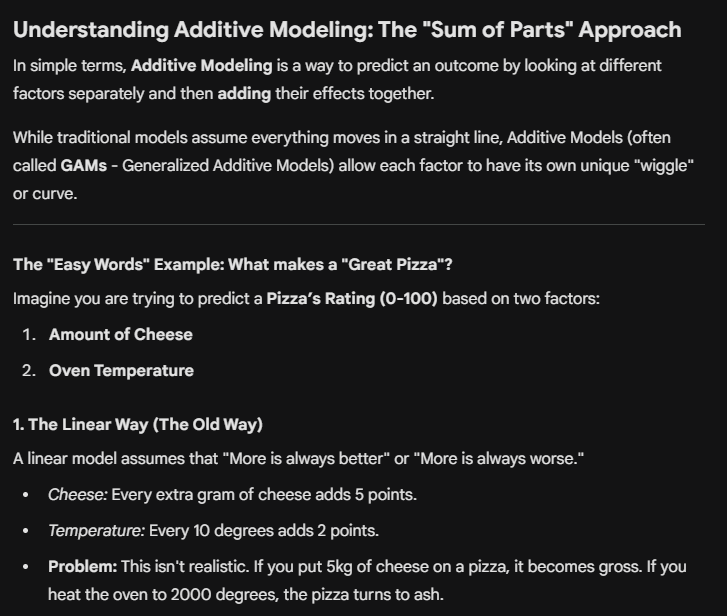
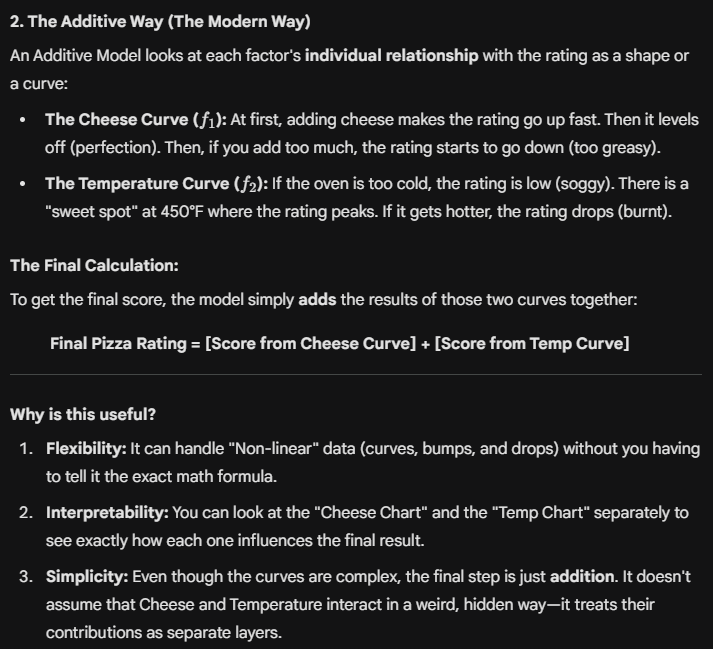
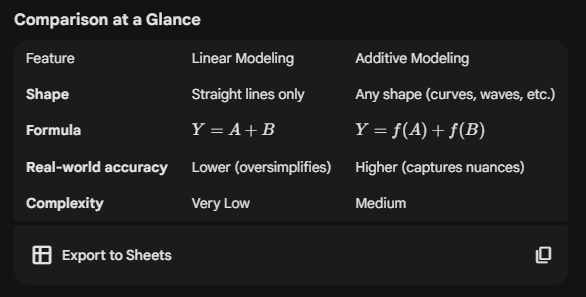